# Ethan Li

## CSCI E-89 Deep Learning, Assignment 03, Problem 3

**Fashion MNIST image classification with a PyTorch MLP.** This notebook loads Fashion MNIST (55,000 training / 5,000 validation / 10,000 test images) and trains a 784-300-100-10 multilayer perceptron with SGD (learning rate 0.1) and cross-entropy for 20 epochs, measuring accuracy with torchmetrics. It then plots training vs. validation accuracy, shows predictions with class probabilities for three validation images, and tunes the learning rate, hidden-layer sizes and momentum with Optuna, comparing the tuned model with the baseline.

The notebook is self-contained: it doesn't import the `prob3/*.py` scripts. Each code cell is the code of one script, in the order the scripts are run. It runs top to bottom with *Kernel → Restart & Run All* in roughly 7 minutes on a CPU; it uses a GPU if one is available.

### The request (prompt quoted word for word)

> Hello! I'd like your help building an image classifier for the Fashion MNIST dataset with PyTorch, from start to finish, in this one request. Work only inside a new folder called prob3/ and ignore any other files in this repo; build everything fresh. Write each major step as a separate Python script and commit each script separately, with a clear commit message, in the order below.
>
> General requirements:
> - Every script must also work when pasted into consecutive Jupyter Notebook cells in the order below (no argparse errors from Jupyter's arguments, plots shown inline, later cells reusing names defined by earlier cells when the .py files aren't available).
> - Keep prob3/PROMPTS.md: log this prompt word for word, and any follow-up requests I make, with the files and commit hashes each one produced.
> - Add a .gitignore for the downloaded dataset, \_\_pycache\_\_/, and .ipynb_checkpoints/.
> - When running things, run one command at a time and never start two training runs at once; they compete for the CPU and slow each other down badly.
>
> Steps:
> 1. data.py: download Fashion MNIST with torchvision, convert the images to float32 tensors and normalize them, set the seed (42), split the 60,000 training images into 55,000 for training and 5,000 for validation, and create DataLoaders with batch size 32 (only the training loader shuffled), plus whatever else is necessary.
> 2. model.py: an MLP classifier as an nn.Module. Flatten the 28x28 image, then two hidden layers of 300 and 100 neurons with ReLU, and an output layer of 10 logits (one per class). Make the hidden sizes configurable.
> 3. train.py: train the model with SGD (learning rate 0.1) and cross-entropy loss for 20 epochs, using torchmetrics to compute multiclass accuracy (plain accuracy: correct / total). For each epoch, record the mean training loss, training accuracy, and validation accuracy and print them. Use a GPU if one is available, otherwise CPU. After training, evaluate accuracy on the test set, save the model weights, and save the history (including test accuracy) to a JSON file.
> 4. plot.py: plot the training accuracy per epoch, with validation accuracy on the same chart for comparison. Save it as a PNG and display it inline in Jupyter. Have train.py call the plotting after training.
> 5. predict.py: use the trained model on the first 3 images of the validation set; print the predicted and true class names, the softmax probabilities for all 10 classes (rounded to 3 decimals), and the top 4 most likely classes for each image.
> 6. tune.py: hyperparameter tuning with Optuna (seeded). Search the learning rate (log scale from about 1e-5 to 1e-1), the number of neurons in each hidden layer, and the SGD momentum. Keep it fast: about 10 trials of 5 epochs each. Print a table of the trials and the best parameters, then retrain the best configuration for 20 epochs and report its test accuracy compared with the baseline from train.py.
>
> Then:
> 7. Run every script in order, one at a time, and fix anything that breaks. Commit the outputs (history JSON, plot PNG, tuning results) along with any fixes.
> 8. Write prob3/SUMMARY.md summarizing this whole session: what I asked for, what you built in each step, problems you ran into and how you fixed them, and the final results (train/validation/test accuracy, baseline vs. tuned). Include a table of scripts with the commit that created each one and the order to run them in.
> 9. Wrap all of the code into one self-contained Jupyter notebook, prob3/e89_Li_Ethan_HW03_Prob3.ipynb. The first cell is markdown with my name (Ethan Li), "CSCI E-89 Deep Learning, Assignment 03, Problem 3", and a short description. Quote this prompt in a markdown cell near the top. Before each code cell, add a markdown cell saying which script it came from and what it does, and add comments in the code. It must not import the .py files, and it must run top to bottom with Restart & Run All. Execute it so the outputs are saved, commit it, and add a short section about it to SUMMARY.md and PROMPTS.md.
>
> When you're done, give me a short list of what was committed and the key results.

### Requirements

`torch`, `torchvision`, `torchmetrics`, `optuna`, `pandas`, `matplotlib`, `numpy`. The dataset downloads automatically into `./data/`. Output files (weights, `history.json`, plots, tuning results) are written to the notebook's folder.

### Step 1 — from `data.py`: load and prepare Fashion MNIST

This cell downloads Fashion MNIST with torchvision and converts the images to float32 tensors, normalized with the mean and std of the training split. It seeds everything with 42, splits the 60,000 training images into 55,000 for training and 5,000 for validation, and builds DataLoaders with batch size 32 (only the training loader is shuffled). It also defines `CLASS_NAMES`, `set_seed()` and `get_dataloaders()`, which later cells use.

In [1]:
# ===== Source: prob3/data.py =====
# Dataset download, normalization, 55k/5k split, DataLoaders.

"""Step 1 — data.py: load Fashion MNIST and build the DataLoaders.

- Downloads Fashion MNIST with torchvision into prob3/data/.
- Converts the uint8 images to float32 tensors in [0, 1] and normalizes them
  with the training-set mean and standard deviation.
- Seeds everything with 42 and splits the 60,000 training images into
  55,000 training / 5,000 validation images.
- Builds DataLoaders with batch size 32 (only the training loader shuffles).

Works as a script (`python data.py`) or pasted into a Jupyter cell.
"""
import random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets

# ---------------------------------------------------------------- constants
SEED = 42
BATCH_SIZE = 32
N_TRAIN, N_VALID = 55_000, 5_000

# Output folder: the folder holding this script, or the notebook's working
# directory when pasted into Jupyter (where __file__ is not defined).
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_DIR = BASE_DIR / "data"

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


def set_seed(seed: int = SEED) -> None:
    """Seed Python, NumPy and PyTorch (CPU and GPU) for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def to_normalized_tensors(dataset, mean=None, std=None):
    """Turn a torchvision dataset into (images, labels) tensors.

    Images become float32 of shape (N, 1, 28, 28), scaled to [0, 1] and then
    standardized with `mean`/`std` (computed from these images if not given).
    Converting everything once up front is much faster than applying a
    per-image transform every time a batch is loaded.
    """
    x = dataset.data.unsqueeze(1).to(torch.float32) / 255.0
    if mean is None:
        mean, std = x.mean().item(), x.std().item()
    x = (x - mean) / std
    y = dataset.targets.clone().long()
    return x, y, mean, std


def get_datasets(data_dir=DATA_DIR, seed: int = SEED):
    """Download Fashion MNIST and return (train_set, valid_set, test_set, stats)."""
    train_full = datasets.FashionMNIST(data_dir, train=True, download=True)
    test_raw = datasets.FashionMNIST(data_dir, train=False, download=True)

    # Split indices first so the normalization statistics come from the
    # 55,000 training images only (no information leaks from validation).
    generator = torch.Generator().manual_seed(seed)
    train_idx, valid_idx = random_split(range(len(train_full)), [N_TRAIN, N_VALID],
                                        generator=generator)
    train_idx, valid_idx = list(train_idx), list(valid_idx)

    x_all = train_full.data.unsqueeze(1).to(torch.float32) / 255.0
    mean = x_all[train_idx].mean().item()
    std = x_all[train_idx].std().item()

    x_full, y_full, _, _ = to_normalized_tensors(train_full, mean, std)
    x_test, y_test, _, _ = to_normalized_tensors(test_raw, mean, std)

    train_set = TensorDataset(x_full[train_idx], y_full[train_idx])
    valid_set = TensorDataset(x_full[valid_idx], y_full[valid_idx])
    test_set = TensorDataset(x_test, y_test)
    return train_set, valid_set, test_set, {"mean": mean, "std": std}


def get_dataloaders(batch_size: int = BATCH_SIZE, seed: int = SEED, data_dir=DATA_DIR):
    """Return (train_loader, valid_loader, test_loader); only training shuffles."""
    set_seed(seed)
    train_set, valid_set, test_set, _ = get_datasets(data_dir, seed)
    # A dedicated seeded generator makes the shuffling order reproducible.
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              generator=torch.Generator().manual_seed(seed))
    valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader


if __name__ == "__main__":
    set_seed(SEED)
    train_set, valid_set, test_set, stats = get_datasets()
    train_loader, valid_loader, test_loader = get_dataloaders()

    print(f"Normalization (from training split): mean={stats['mean']:.4f}, std={stats['std']:.4f}")
    print(f"Train / valid / test sizes: {len(train_set)} / {len(valid_set)} / {len(test_set)}")
    print(f"Batches per epoch: train={len(train_loader)}, valid={len(valid_loader)}, "
          f"test={len(test_loader)}")
    images, labels = next(iter(train_loader))
    print(f"One batch: images {tuple(images.shape)} {images.dtype}, labels {tuple(labels.shape)}")
    print("First labels:", [CLASS_NAMES[i] for i in labels[:5].tolist()])


Normalization (from training split): mean=0.2856, std=0.3527
Train / valid / test sizes: 55000 / 5000 / 10000
Batches per epoch: train=1719, valid=157, test=313
One batch: images (32, 1, 28, 28) torch.float32, labels (32,)
First labels: ['T-shirt/top', 'Shirt', 'Sneaker', 'Shirt', 'Trouser']


### Step 2 — from `model.py`: the MLP classifier

This cell defines `MLP`, an `nn.Module` that flattens each 28×28 image and passes it through two ReLU hidden layers (300 and 100 neurons by default; configurable with `hidden_sizes`) to an output layer of 10 logits. It prints the architecture and the parameter count.

In [2]:
# ===== Source: prob3/model.py =====
# MLP: Flatten -> 300 -> ReLU -> 100 -> ReLU -> 10 logits.

"""Step 2 — model.py: the MLP classifier.

Flatten (28x28 -> 784) -> Linear(300) -> ReLU -> Linear(100) -> ReLU -> Linear(10).
The output layer returns raw logits (one per class); CrossEntropyLoss applies
the softmax internally. Hidden sizes are configurable via `hidden_sizes`.
"""
import torch
from torch import nn


class MLP(nn.Module):
    """Multilayer perceptron for 28x28 grayscale images and 10 classes."""

    def __init__(self, hidden_sizes=(300, 100), input_size: int = 28 * 28,
                 num_classes: int = 10):
        super().__init__()
        self.hidden_sizes = tuple(hidden_sizes)
        layers = [nn.Flatten()]
        in_features = input_size
        for size in self.hidden_sizes:
            layers += [nn.Linear(in_features, size), nn.ReLU()]
            in_features = size
        layers.append(nn.Linear(in_features, num_classes))  # logits, no softmax
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def count_parameters(model: nn.Module) -> int:
    """Number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


if __name__ == "__main__":
    model = MLP()
    print(model)
    print(f"Trainable parameters: {count_parameters(model):,}")
    # Sanity check: a dummy batch of 32 images gives 32 x 10 logits.
    print("Output shape for a batch of 32:", tuple(model(torch.zeros(32, 1, 28, 28)).shape))


MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610
Output shape for a batch of 32: (32, 10)


### Step 3 — from `train.py`: train and evaluate the baseline

This cell trains the MLP for 20 epochs with SGD (learning rate 0.1) and cross-entropy loss. Plain accuracy (correct / total) comes from torchmetrics' `MulticlassAccuracy(average="micro")`. Each epoch prints and records the mean training loss, training accuracy and validation accuracy. Afterwards the cell evaluates on the test set and saves the weights (`mlp_fashion_mnist.pt`) and the history (`history.json`).

In [3]:
# ===== Source: prob3/train.py =====
# SGD training loop, torchmetrics accuracy, test evaluation, saving.

"""Step 3 — train.py: train the MLP with SGD and evaluate it.

- SGD, learning rate 0.1, cross-entropy loss, 20 epochs.
- torchmetrics MulticlassAccuracy with average="micro" = plain accuracy
  (correct / total). Note: torchmetrics defaults to average="macro", which is
  the mean of per-class accuracies, so "micro" has to be set explicitly.
- Per epoch: mean training loss, training accuracy, validation accuracy.
- Afterwards: test accuracy, model weights (.pt), history (.json), and the
  accuracy plot from plot.py.
"""
import json
import time

import torch
from torch import nn
from torchmetrics.classification import MulticlassAccuracy


EPOCHS = 20
LEARNING_RATE = 0.1
WEIGHTS_PATH = BASE_DIR / "mlp_fashion_mnist.pt"
HISTORY_PATH = BASE_DIR / "history.json"

# Use a GPU if one is available, otherwise the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def make_accuracy(device):
    """Plain multiclass accuracy (correct / total) as a torchmetrics metric."""
    return MulticlassAccuracy(num_classes=10, average="micro").to(device)


def train_one_epoch(model, loader, loss_fn, optimizer, device):
    """One pass over `loader`; returns (mean training loss, training accuracy).

    The training accuracy is accumulated over the batches while the weights
    are being updated (like Keras reports it).
    """
    model.train()
    accuracy = make_accuracy(device)
    total_loss, n_samples = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)  # sum of per-sample losses
        n_samples += labels.size(0)
        accuracy.update(logits.detach(), labels)
    return total_loss / n_samples, accuracy.compute().item()


@torch.no_grad()
def evaluate(model, loader, device):
    """Accuracy of `model` on every batch of `loader`."""
    model.eval()
    accuracy = make_accuracy(device)
    for images, labels in loader:
        accuracy.update(model(images.to(device)), labels.to(device))
    return accuracy.compute().item()


def fit(model, train_loader, valid_loader, epochs=EPOCHS, lr=LEARNING_RATE,
        momentum=0.0, device=device, verbose=True):
    """Train with SGD + cross-entropy; returns the per-epoch history dict."""
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    history = {"epoch": [], "train_loss": [], "train_accuracy": [], "val_accuracy": []}
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_acc = evaluate(model, valid_loader, device)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs}  train_loss={train_loss:.4f}  "
                  f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  "
                  f"({time.time() - start:.1f}s)")
    return history


if __name__ == "__main__":
    print(f"Using device: {device}")
    set_seed(SEED)
    train_loader, valid_loader, test_loader = get_dataloaders()
    model = MLP(hidden_sizes=(300, 100))

    history = fit(model, train_loader, valid_loader, epochs=EPOCHS, lr=LEARNING_RATE)

    test_acc = evaluate(model, test_loader, device)
    history["test_accuracy"] = test_acc
    history["config"] = {"hidden_sizes": [300, 100], "lr": LEARNING_RATE, "momentum": 0.0,
                         "epochs": EPOCHS, "batch_size": train_loader.batch_size,
                         "seed": SEED, "device": str(device)}
    print(f"\nFinal: train_acc={history['train_accuracy'][-1]:.4f}  "
          f"val_acc={history['val_accuracy'][-1]:.4f}  test_acc={test_acc:.4f}")

    torch.save(model.state_dict(), WEIGHTS_PATH)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)
    print(f"Saved weights to {WEIGHTS_PATH.name} and history to {HISTORY_PATH.name}")

    # plot.py's plot_history() is defined in the next cell, which draws
    # the accuracy chart from this `history` dict.


Using device: cpu


Epoch  1/20  train_loss=0.4927  train_acc=0.8182  val_acc=0.8558  (3.6s)


Epoch  2/20  train_loss=0.3597  train_acc=0.8662  val_acc=0.8612  (3.4s)


Epoch  3/20  train_loss=0.3169  train_acc=0.8821  val_acc=0.8722  (3.5s)


Epoch  4/20  train_loss=0.2910  train_acc=0.8904  val_acc=0.8772  (3.5s)


...

Epoch 17/20  train_loss=0.1469  train_acc=0.9441  val_acc=0.8856  (3.4s)


Epoch 18/20  train_loss=0.1378  train_acc=0.9469  val_acc=0.8916  (3.5s)


Epoch 19/20  train_loss=0.1334  train_acc=0.9491  val_acc=0.8882  (3.6s)


Epoch 20/20  train_loss=0.1278  train_acc=0.9505  val_acc=0.8908  (3.5s)



Final: train_acc=0.9505  val_acc=0.8908  test_acc=0.8894
Saved weights to mlp_fashion_mnist.pt and history to history.json


### Step 4 — from `plot.py`: training vs. validation accuracy

This cell plots training and validation accuracy per epoch on one chart, with the test accuracy as a dashed line. It saves the chart as `accuracy.png` and shows it inline below.

Saved plot to accuracy.png


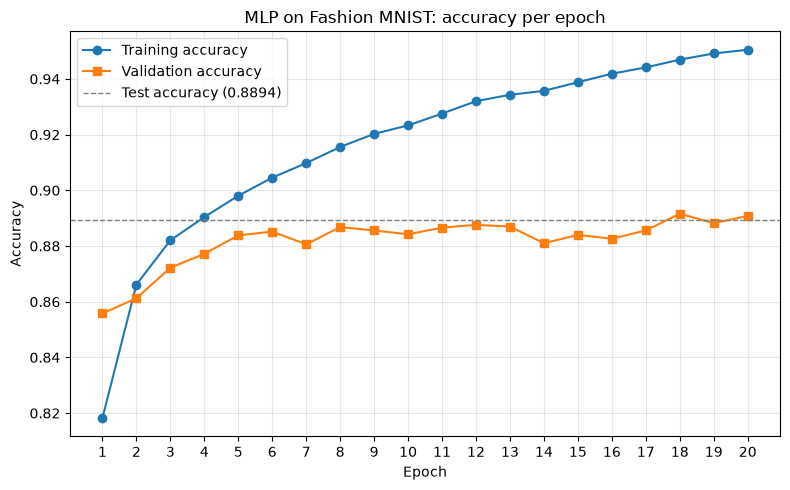

In [4]:
# ===== Source: prob3/plot.py =====
# Accuracy-per-epoch chart: saved as PNG, shown inline.

"""Step 4 — plot.py: plot training vs. validation accuracy per epoch.

Saves the chart as a PNG and shows it inline when running inside Jupyter.
train.py calls `plot_history` after training; run on its own, this script
reads the saved history.json.
"""
import json
import sys
from pathlib import Path

import matplotlib

# Outside Jupyter, use the non-interactive Agg backend so the script also
# works on machines without a display. Inside Jupyter keep the inline backend.
IN_JUPYTER = "ipykernel" in sys.modules
if not IN_JUPYTER:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PLOT_PATH = BASE_DIR / "accuracy.png"


def plot_history(history, path=PLOT_PATH, title="MLP on Fashion MNIST: accuracy per epoch"):
    """Plot train and validation accuracy from a history dict, save it as a PNG."""
    epochs = history.get("epoch") or list(range(1, len(history["train_accuracy"]) + 1))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, history["train_accuracy"], marker="o", label="Training accuracy")
    ax.plot(epochs, history["val_accuracy"], marker="s", label="Validation accuracy")
    if "test_accuracy" in history:
        ax.axhline(history["test_accuracy"], color="gray", linestyle="--", linewidth=1,
                   label=f"Test accuracy ({history['test_accuracy']:.4f})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.set_xticks(epochs)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=120)
    print(f"Saved plot to {Path(path).name}")
    if IN_JUPYTER:
        plt.show()  # displayed inline in the notebook
    else:
        plt.close(fig)
    return path


if __name__ == "__main__":
    # In Jupyter, reuse the `history` dict from the train.py cell if present;
    # otherwise load the history saved by train.py.
    if "history" not in globals():
        with open(BASE_DIR / "history.json") as f:
            history = json.load(f)
    plot_history(history)


### Step 5 — from `predict.py`: predictions for 3 validation images

This cell loads the trained weights and classifies the first 3 validation images. For each one it prints the predicted and true class names, the softmax probability of every class (3 decimals), and the top 4 most likely classes.

In [5]:
# ===== Source: prob3/predict.py =====
# Predictions, softmax probabilities and top-4 classes.

"""Step 5 — predict.py: predictions for the first 3 validation images.

For each image prints the predicted and true class names, the softmax
probabilities for all 10 classes (rounded to 3 decimals), and the top 4
most likely classes. Uses the weights saved by train.py.
"""
import torch


N_IMAGES = 3
TOP_K = 4


@torch.no_grad()
def predict_proba(model, images, device="cpu"):
    """Softmax class probabilities for a batch of images."""
    model.eval()
    logits = model(images.to(device))
    return torch.softmax(logits, dim=1).cpu()


def show_predictions(probs, labels, class_names=CLASS_NAMES, top_k=TOP_K):
    """Print prediction, truth, all probabilities and the top-k classes per image."""
    for i, (p, true) in enumerate(zip(probs, labels)):
        pred = int(p.argmax())
        status = "correct" if pred == int(true) else "WRONG"
        print(f"Validation image {i}: predicted = {class_names[pred]!r}, "
              f"true = {class_names[int(true)]!r} ({status})")
        print("  Probabilities (3 decimals):")
        for name, prob in zip(class_names, p.tolist()):
            print(f"    {name:<12} {prob:.3f}")
        top_p, top_i = torch.topk(p, top_k)
        top = ", ".join(f"{class_names[j]} ({q:.3f})" for q, j in zip(top_p.tolist(), top_i.tolist()))
        print(f"  Top {top_k}: {top}\n")


if __name__ == "__main__":
    set_seed(SEED)
    # The validation split is seeded, so these are the same 3 images every run.
    _, valid_set, _, _ = get_datasets()
    images, labels = valid_set[:N_IMAGES]

    # Load the trained baseline model saved by train.py.
    trained = MLP(hidden_sizes=(300, 100))
    trained.load_state_dict(torch.load(BASE_DIR / "mlp_fashion_mnist.pt", map_location="cpu"))

    probs = predict_proba(trained, images)
    show_predictions(probs, labels)


Validation image 0: predicted = 'Sneaker', true = 'Sneaker' (correct)
  Probabilities (3 decimals):
    T-shirt/top  0.000
    Trouser      0.000
    Pullover     0.000
    Dress        0.000
    Coat         0.000
    Sandal       0.000
    Shirt        0.000
    Sneaker      0.999
    Bag          0.000
    Ankle boot   0.000
  Top 4: Sneaker (0.999), Ankle boot (0.000), Sandal (0.000), Coat (0.000)

Validation image 1: predicted = 'Coat', true = 'Coat' (correct)
  Probabilities (3 decimals):
    T-shirt/top  0.000
    Trouser      0.000
    Pullover     0.005
    Dress        0.000
    Coat         0.995
    Sandal       0.000
    Shirt        0.000
    Sneaker      0.000
    Bag          0.000
    Ankle boot   0.000
  Top 4: Coat (0.995), Pullover (0.005), Shirt (0.000), Dress (0.000)

Validation image 2: predicted = 'Pullover', true = 'Pullover' (correct)
  Probabilities (3 decimals):
    T-shirt/top  0.000
    Trouser      0.000
    Pullover     0.987
    Dress        0.000
    C

### Step 6 — from `tune.py`: hyperparameter tuning with Optuna

This cell runs a seeded TPE search: 10 trials of 5 epochs each, maximizing validation accuracy. It searches the learning rate (log scale, 1e-5 to 1e-1), the neurons in each hidden layer, and the SGD momentum. It prints the table of trials and the best parameters, retrains the best configuration for 20 epochs, and compares its test accuracy with the baseline from Step 3.

Trial 0: lr=3.15e-04 hidden=(478, 223) momentum=0.593 -> val_acc=0.7818


Trial 1: lr=4.21e-05 hidden=(120, 26) momentum=0.858 -> val_acc=0.6970


Trial 2: lr=2.54e-03 hidden=(369, 15) momentum=0.960 -> val_acc=0.8760


Trial 3: lr=2.14e-02 hidden=(145, 62) momentum=0.182 -> val_acc=0.8744


Trial 4: lr=1.65e-04 hidden=(286, 135) momentum=0.288 -> val_acc=0.6930


...

Epoch 18/20  train_loss=0.1522  train_acc=0.9427  val_acc=0.8894  (3.6s)


Epoch 19/20  train_loss=0.1465  train_acc=0.9453  val_acc=0.8884  (3.8s)


Epoch 20/20  train_loss=0.1407  train_acc=0.9465  val_acc=0.8888  (3.7s)



Baseline vs. tuned (after 20 epochs):
            train_acc   val_acc  test_acc
baseline       0.9505    0.8908    0.8894
tuned          0.9465    0.8888    0.8875
Test accuracy change: -0.0019 (-0.19 percentage points)
Saved optuna_trials.csv, tuning_results.json, mlp_fashion_mnist_tuned.pt


Saved plot to accuracy_tuned.png


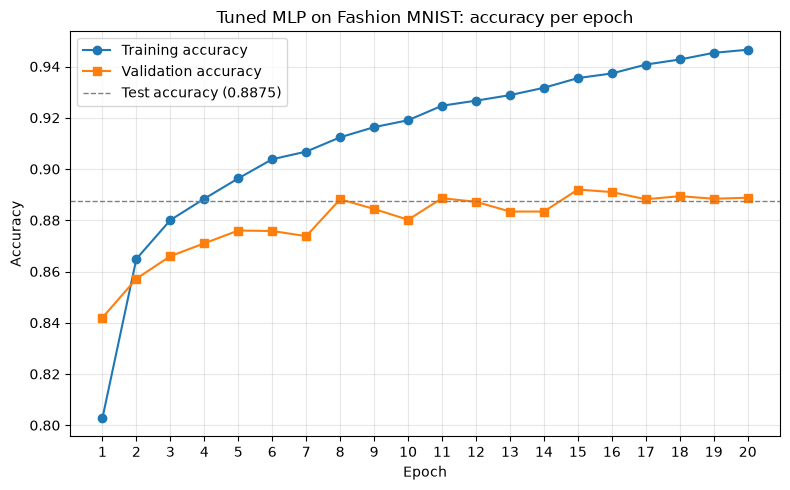

In [6]:
# ===== Source: prob3/tune.py =====
# Optuna search, best-config retrain, baseline comparison.

"""Step 6 — tune.py: hyperparameter tuning with Optuna.

Search space (seeded TPE sampler, 10 trials x 5 epochs, maximize validation
accuracy):
- learning rate: log scale, 1e-5 .. 1e-1
- neurons in hidden layer 1: 50 .. 500
- neurons in hidden layer 2: 10 .. 300
- SGD momentum: 0.0 .. 0.99

Then retrains the best configuration for 20 epochs and compares its test
accuracy with the baseline from train.py.
"""
import json
import warnings

# Optuna imports tqdm.auto, which warns "IProgress not found" in Jupyter when
# ipywidgets is not installed; progress bars are not used here, so silence it.
warnings.filterwarnings("ignore", message="IProgress not found")
import optuna
import pandas as pd
import torch


N_TRIALS = 10
TRIAL_EPOCHS = 5
TRIALS_CSV = BASE_DIR / "optuna_trials.csv"
RESULTS_JSON = BASE_DIR / "tuning_results.json"
TUNED_WEIGHTS = BASE_DIR / "mlp_fashion_mnist_tuned.pt"
TUNED_PLOT = BASE_DIR / "accuracy_tuned.png"


def objective(trial):
    """Train a sampled configuration for TRIAL_EPOCHS; return validation accuracy."""
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    n_hidden1 = trial.suggest_int("n_hidden1", 50, 500)
    n_hidden2 = trial.suggest_int("n_hidden2", 10, 300)
    momentum = trial.suggest_float("momentum", 0.0, 0.99)

    set_seed(SEED)  # same initialization/shuffling for every trial
    train_loader, valid_loader, _ = get_dataloaders()
    model = MLP(hidden_sizes=(n_hidden1, n_hidden2))
    hist = fit(model, train_loader, valid_loader, epochs=TRIAL_EPOCHS, lr=lr,
               momentum=momentum, device=device, verbose=False)
    val_acc = hist["val_accuracy"][-1]
    print(f"Trial {trial.number}: lr={lr:.2e} hidden=({n_hidden1}, {n_hidden2}) "
          f"momentum={momentum:.3f} -> val_acc={val_acc:.4f}")
    return val_acc


if __name__ == "__main__":
    optuna.logging.set_verbosity(optuna.logging.WARNING)  # we print our own lines
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS)

    # Table of all trials.
    trials_df = study.trials_dataframe(attrs=("number", "value", "params", "duration"))
    trials_df = trials_df.rename(columns={"value": "val_accuracy"})
    trials_df.columns = [c.replace("params_", "") for c in trials_df.columns]
    trials_df["duration"] = trials_df["duration"].dt.total_seconds().round(1)
    trials_df.to_csv(TRIALS_CSV, index=False)
    with pd.option_context("display.width", 120, "display.max_columns", None):
        print("\nOptuna trials:")
        print(trials_df.round({"val_accuracy": 4, "lr": 6, "momentum": 3}).to_string(index=False))

    best = study.best_params
    print(f"\nBest trial: #{study.best_trial.number}, val_acc={study.best_value:.4f}")
    print("Best parameters:", best)

    # Retrain the best configuration for the full 20 epochs.
    print(f"\nRetraining the best configuration for {EPOCHS} epochs:")
    set_seed(SEED)
    train_loader, valid_loader, test_loader = get_dataloaders()
    tuned_model = MLP(hidden_sizes=(best["n_hidden1"], best["n_hidden2"]))
    tuned_history = fit(tuned_model, train_loader, valid_loader, epochs=EPOCHS,
                        lr=best["lr"], momentum=best["momentum"], device=device)
    tuned_test_acc = evaluate(tuned_model, test_loader, device)
    tuned_history["test_accuracy"] = tuned_test_acc
    torch.save(tuned_model.state_dict(), TUNED_WEIGHTS)

    # Baseline from train.py: the `history` dict from the train.py cell in
    # Jupyter, otherwise the history.json that train.py saved.
    if "history" in globals() and "test_accuracy" in globals()["history"]:
        baseline = globals()["history"]
    else:
        with open(BASE_DIR / "history.json") as f:
            baseline = json.load(f)

    print("\nBaseline vs. tuned (after 20 epochs):")
    print(f"{'':10}{'train_acc':>11}{'val_acc':>10}{'test_acc':>10}")
    for name, h in [("baseline", baseline), ("tuned", tuned_history)]:
        print(f"{name:10}{h['train_accuracy'][-1]:11.4f}{h['val_accuracy'][-1]:10.4f}"
              f"{h['test_accuracy']:10.4f}")
    diff = tuned_test_acc - baseline["test_accuracy"]
    print(f"Test accuracy change: {diff:+.4f} ({diff * 100:+.2f} percentage points)")

    results = {
        "n_trials": N_TRIALS, "trial_epochs": TRIAL_EPOCHS, "sampler": f"TPESampler(seed={SEED})",
        "best_trial": study.best_trial.number, "best_val_accuracy_5_epochs": study.best_value,
        "best_params": best,
        "trials": trials_df.to_dict(orient="records"),
        "tuned_history": tuned_history,
        "baseline_test_accuracy": baseline["test_accuracy"],
        "tuned_test_accuracy": tuned_test_acc,
    }
    with open(RESULTS_JSON, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved {TRIALS_CSV.name}, {RESULTS_JSON.name}, {TUNED_WEIGHTS.name}")

    # Accuracy curves of the tuned model (plot_history is from the plot.py cell).
    plot_history(tuned_history, path=TUNED_PLOT,
                 title="Tuned MLP on Fashion MNIST: accuracy per epoch")


### Results

Everything is seeded (42), so a CPU run reproduces these numbers.

| After 20 epochs | Train acc | Validation acc | Test acc |
|---|---|---|---|
| Baseline (lr 0.1, 300/100, momentum 0) | 0.9505 | 0.8908 | 0.8894 |
| Tuned (lr 2.54e-3, 369/15, momentum 0.960) | 0.9465 | 0.8888 | 0.8875 |

- All 3 validation images in Step 5 are classified correctly: Sneaker, Coat and Pullover.
- Validation accuracy levels off near 0.885–0.89 after about 5 epochs while training accuracy keeps rising, which is mild overfitting.
- The Optuna configuration does **not** beat the baseline (−0.19 percentage points on test, within noise). The budget is small: 10 trials × 5 epochs, with most learning rates sampled far below what works in 5 epochs. The baseline's lr = 0.1 is already a strong setting for this model.